# Visualización de datos — World Cup Insights

**Curso:** BD-143 Programación II — II Cuatrimestre 2026

Este notebook invoca la clase `Visualizador` para construir los gráficos del
proyecto. **Cada gráfico responde a una pregunta concreta** y viene acompañado
de su lectura analítica.

Todas las figuras se guardan además en `reports/figuras/`.

## 1. Configuración

In [1]:
import sys
import os

import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from src.ingesta.cargador import CargadorDatos
from src.gestor.gestor import GestorPartidos
from src.visualizacion.visualizador import Visualizador
from src.helpers.utilidades import Utilidades

# Los gráficos se muestran dentro del notebook.
%matplotlib inline

print('Listo.')

Listo.


## 2. Carga del dataset procesado

Se lee el CSV que generó el sistema en el notebook anterior. Si el archivo aún
no existe, ejecute primero `01_EDA.ipynb` o `python main.py`.

In [2]:
cargador = CargadorDatos(
    ruta_processed=Utilidades.ruta_proyecto('data', 'processed', 'partidos-mundial-procesado.csv'),
)

df = cargador.cargar_procesado()
gestor = GestorPartidos(df)

print(f'Partidos cargados: {len(df)}')
df.head(3)

Partidos cargados: 1068


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,total_goals,goal_diff,winner,decada,es_empate
0,1930-07-13,Belgium,United States,0,3,FIFA World Cup,Montevideo,Uruguay,True,1930,3,-3,Visitante,1930,False
1,1930-07-13,France,Mexico,4,1,FIFA World Cup,Montevideo,Uruguay,True,1930,5,3,Local,1930,False
2,1930-07-14,Brazil,Yugoslavia,1,2,FIFA World Cup,Montevideo,Uruguay,True,1930,3,-1,Visitante,1930,False


## 3. Instanciar el visualizador

`guardar=True` hace que cada figura se escriba como PNG en `reports/figuras/`.

In [3]:
viz = Visualizador(df, guardar=True)

## 4. ¿Cuántos goles se ven en un partido de Mundial?

Distribución del total de goles por partido.

[OK] Grafico guardado: C:\Users\Daniel Nájera\Documents\GitHub\Proyecto2Programacion\world_cup_insights\reports\figuras\01_histograma_goles.png


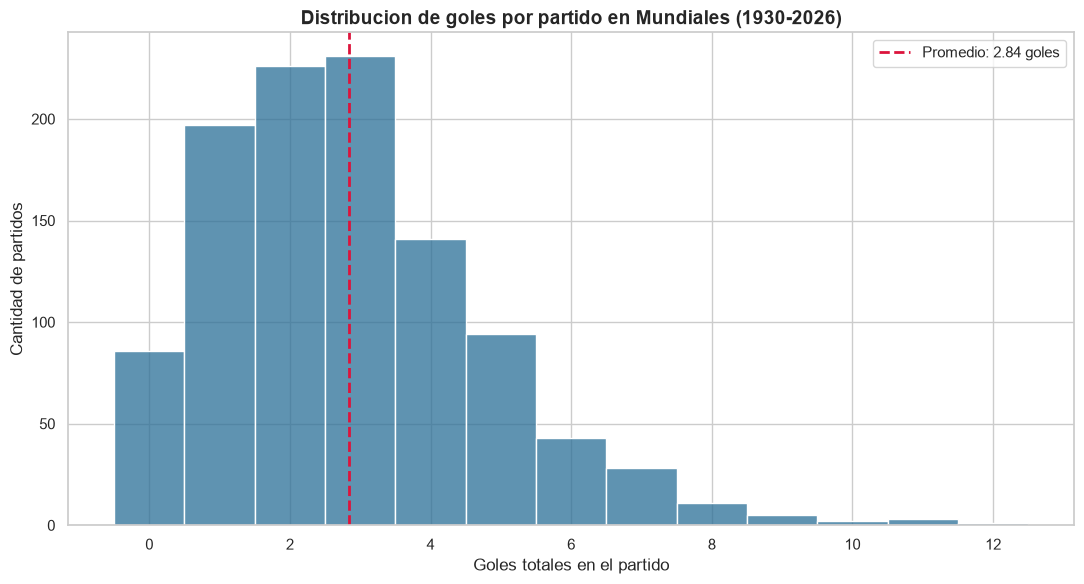

In [4]:
viz.histograma_goles()
plt.show()

**Lectura:** la distribución está sesgada a la derecha. Lo habitual es un
partido de 2 o 3 goles; a partir de 6 la frecuencia cae abruptamente. La media
(2.84) queda por encima de la moda, que es el efecto típico de las goleadas
poco frecuentes tirando del promedio hacia arriba.

## 5. El hallazgo principal: la ventaja de local


[OK] Grafico guardado: C:\Users\Daniel Nájera\Documents\GitHub\Proyecto2Programacion\world_cup_insights\reports\figuras\02_ventaja_local.png


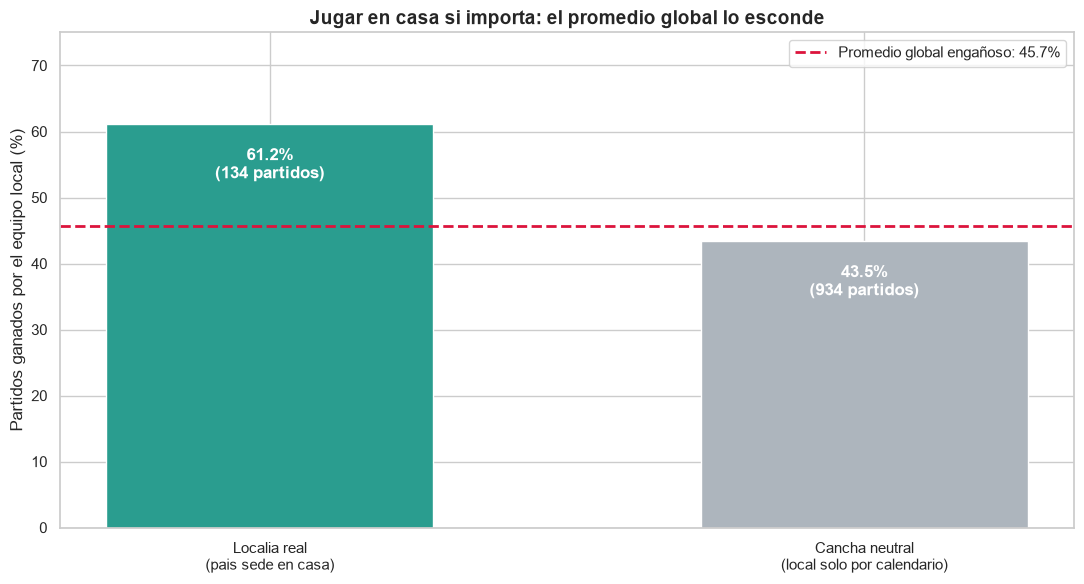

In [5]:
viz.ventaja_local_real()
plt.show()

**Lectura:** el promedio global de 45.7 % sugiere que jugar de local casi no
importa. Es falso. Separando los partidos:

- **Localía real** (el país sede juega en su casa): gana el **61.2 %**
- **Cancha neutral** (local sólo por calendario): gana el **43.5 %**

Casi 18 puntos de diferencia. El promedio global engaña porque el 87 % de los
partidos de Mundial son en cancha neutral, y ese grupo mayoritario arrastra la
media. Es una **paradoja de Simpson** en datos reales.

## 6. ¿El fútbol se volvió más defensivo?

Promedio de goles por partido en cada edición.

[OK] Grafico guardado: C:\Users\Daniel Nájera\Documents\GitHub\Proyecto2Programacion\world_cup_insights\reports\figuras\03_evolucion_goles.png


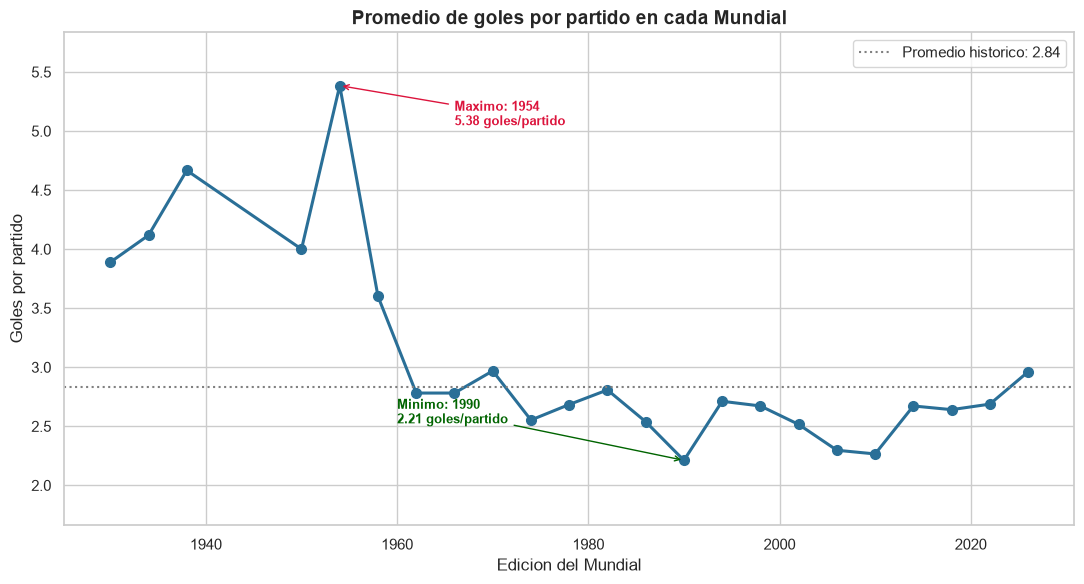

In [6]:
viz.evolucion_goles_por_edicion()
plt.show()

**Lectura:** hay una caída estructural clara. El pico fue **1954 con 5.38 goles
por partido**; el piso, **1990 con 2.21**. Desde entonces el promedio se
estabilizó alrededor de 2.6, sin volver nunca a los niveles previos a 1960.

La explicación habitual es táctica: la profesionalización de la defensa y
sistemas más organizados a partir de los años 60.

> **Nota metodológica:** se grafica el *promedio* y no el total de goles,
> porque el número de partidos por edición pasó de 18 (1930) a 104 (2026).
> Los totales no serían comparables entre ediciones.

## 7. ¿Cómo se relacionan las variables del marcador?

[OK] Grafico guardado: C:\Users\Daniel Nájera\Documents\GitHub\Proyecto2Programacion\world_cup_insights\reports\figuras\04_heatmap_correlacion.png


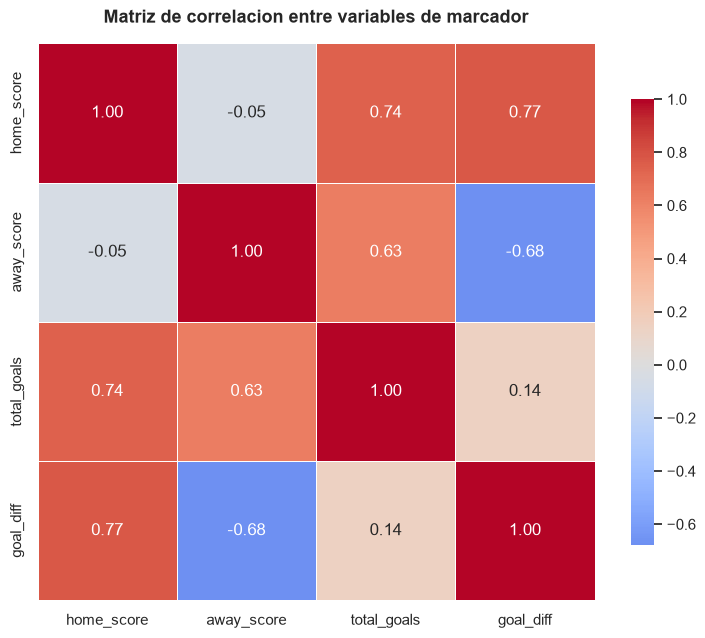

In [7]:
viz.heatmap_correlacion()
plt.show()

**Lectura:** la correlación entre `home_score` y `away_score` es **negativa**.
Cuando un equipo marca mucho, el rival tiende a marcar poco: los partidos de
Mundial son más desequilibrados que parejos. Las correlaciones fuertes con
`total_goals` y `goal_diff` son esperables, ya que son columnas derivadas.

## 8. ¿Qué selección domina el histórico?

[OK] Grafico guardado: C:\Users\Daniel Nájera\Documents\GitHub\Proyecto2Programacion\world_cup_insights\reports\figuras\05_top_equipos.png


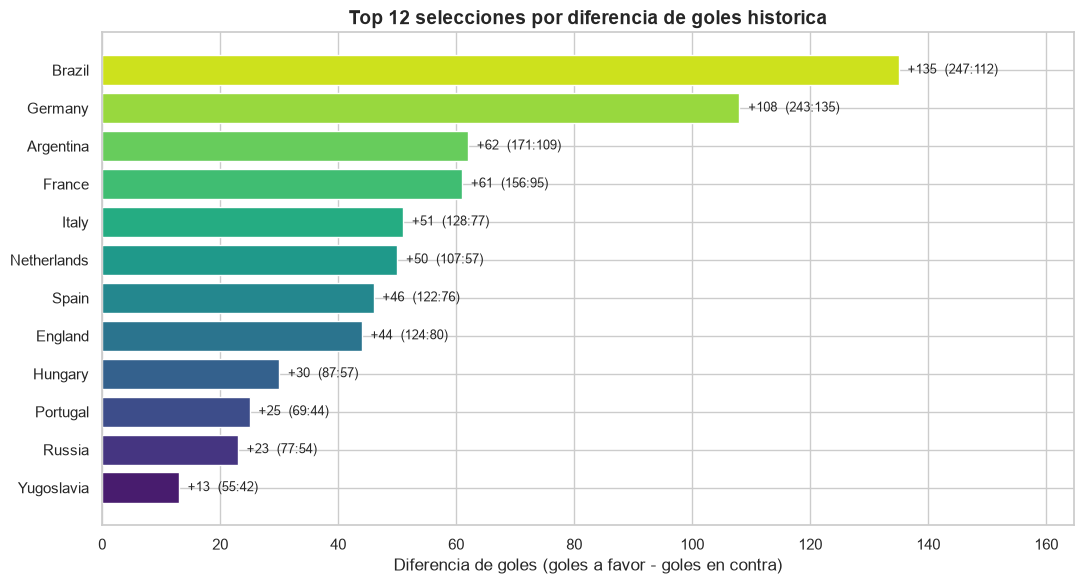

In [8]:
tabla = gestor.tabla_historica()
viz.top_equipos_diferencia(tabla)
plt.show()

**Lectura:** **Brasil** encabeza con **+135** de diferencia de goles, seguido
de **Alemania (+108)** y **Argentina (+62)**. La brecha entre Brasil y el resto
es notable, y se explica tanto por su rendimiento como por ser la única
selección presente en las 23 ediciones.

## 9. Ataque contra defensa

[OK] Grafico guardado: C:\Users\Daniel Nájera\Documents\GitHub\Proyecto2Programacion\world_cup_insights\reports\figuras\06_ataque_defensa.png


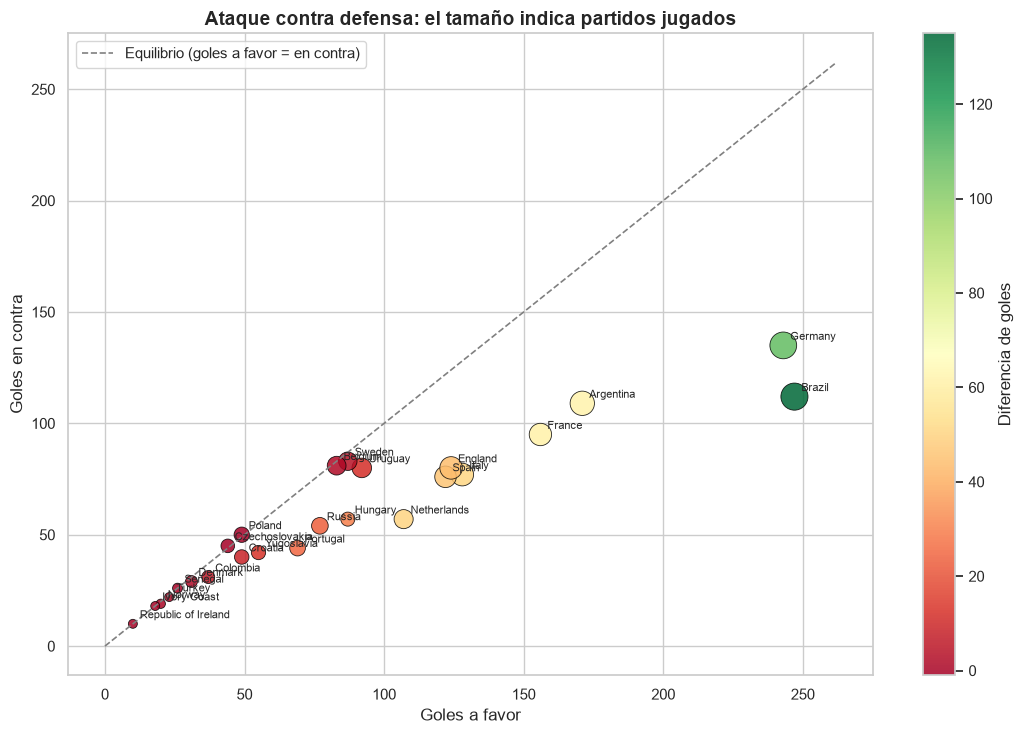

In [9]:
viz.dispersion_ataque_defensa(tabla)
plt.show()

**Lectura:** los equipos por debajo de la diagonal tienen saldo positivo. El
tamaño del punto indica partidos jugados y el color la diferencia de goles.
Se distinguen dos perfiles: selecciones de ataque potente (Brasil, Alemania,
arriba a la derecha) y selecciones que construyeron su historia sobre la
solidez defensiva, como Italia, con muchos menos goles a favor pero también
muy pocos en contra.

## 10. ¿El país sede gana más?

[OK] Grafico guardado: C:\Users\Daniel Nájera\Documents\GitHub\Proyecto2Programacion\world_cup_insights\reports\figuras\07_rendimiento_sedes.png


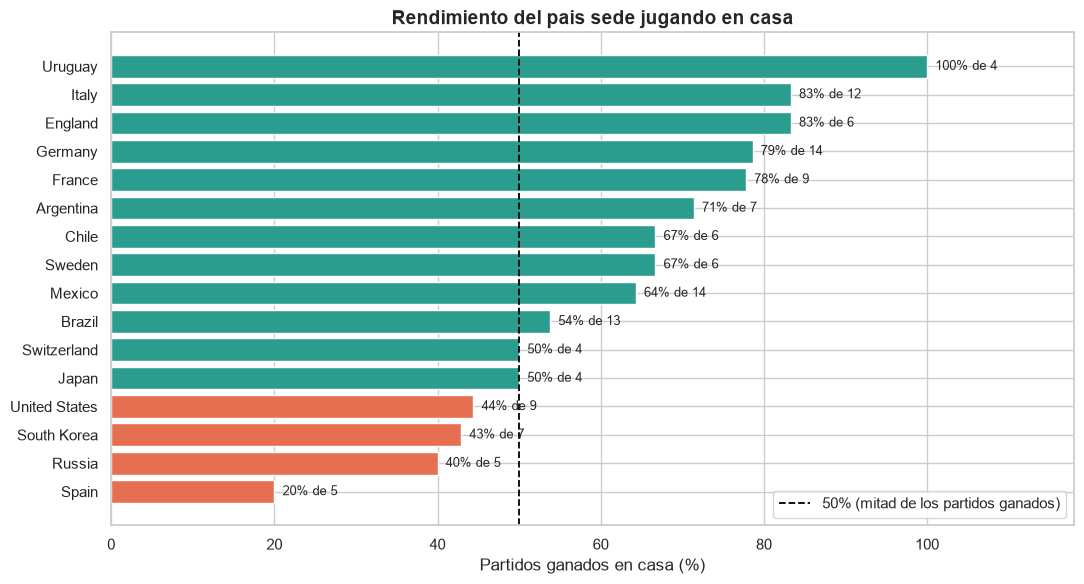

In [10]:
sedes = gestor.rendimiento_pais_sede()
viz.rendimiento_sedes(sedes)
plt.show()

**Lectura:** sí, y de forma consistente. Casi todas las sedes superan el 50 %
de victorias en casa: Uruguay ganó los 4 partidos que jugó como anfitrión en
1930, e Inglaterra (83 %), Italia (83 %) y Alemania (79 %) también rinden muy
por encima de su promedio histórico. Es la confirmación visual del hallazgo
del gráfico 5.

## 11. ¿Cómo termina un partido de Mundial?

[OK] Grafico guardado: C:\Users\Daniel Nájera\Documents\GitHub\Proyecto2Programacion\world_cup_insights\reports\figuras\08_distribucion_resultados.png


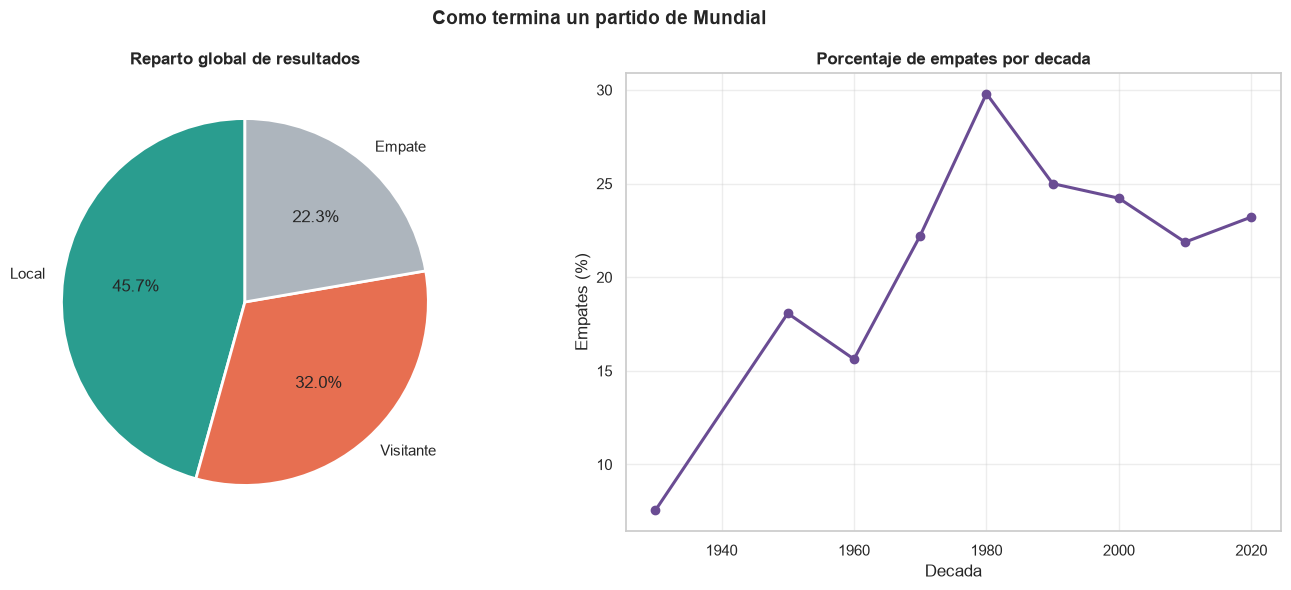

In [11]:
viz.distribucion_resultados()
plt.show()

**Lectura:** el reparto global es de aproximadamente 46 % victorias del local,
32 % del visitante y 22 % empates. El panel derecho muestra la evolución de los
empates por década: crecen junto con la caída de goles, lo que refuerza la
lectura de un torneo tácticamente más cerrado.

## 12. Versión interactiva (Plotly)

Al pasar el mouse sobre cada punto se muestran los partidos jugados y los
goles totales de esa edición.

In [12]:
fig = viz.grafico_interactivo_goles()
fig.show()

[OK] Grafico interactivo guardado: C:\Users\Daniel Nájera\Documents\GitHub\Proyecto2Programacion\world_cup_insights\reports\figuras\09_interactivo_goles.html


## 13. Generar toda la batería de gráficos

Regenera los ocho PNG de `reports/figuras/` en una sola llamada.

[OK] Grafico guardado: C:\Users\Daniel Nájera\Documents\GitHub\Proyecto2Programacion\world_cup_insights\reports\figuras\01_histograma_goles.png


[OK] Grafico guardado: C:\Users\Daniel Nájera\Documents\GitHub\Proyecto2Programacion\world_cup_insights\reports\figuras\02_ventaja_local.png


[OK] Grafico guardado: C:\Users\Daniel Nájera\Documents\GitHub\Proyecto2Programacion\world_cup_insights\reports\figuras\03_evolucion_goles.png


[OK] Grafico guardado: C:\Users\Daniel Nájera\Documents\GitHub\Proyecto2Programacion\world_cup_insights\reports\figuras\04_heatmap_correlacion.png


[OK] Grafico guardado: C:\Users\Daniel Nájera\Documents\GitHub\Proyecto2Programacion\world_cup_insights\reports\figuras\05_top_equipos.png


[OK] Grafico guardado: C:\Users\Daniel Nájera\Documents\GitHub\Proyecto2Programacion\world_cup_insights\reports\figuras\06_ataque_defensa.png


[OK] Grafico guardado: C:\Users\Daniel Nájera\Documents\GitHub\Proyecto2Programacion\world_cup_insights\reports\figuras\07_rendimiento_sedes.png


[OK] Grafico guardado: C:\Users\Daniel Nájera\Documents\GitHub\Proyecto2Programacion\world_cup_insights\reports\figuras\08_distribucion_resultados.png

[OK] Todos los graficos estan en: C:\Users\Daniel Nájera\Documents\GitHub\Proyecto2Programacion\world_cup_insights\reports\figuras


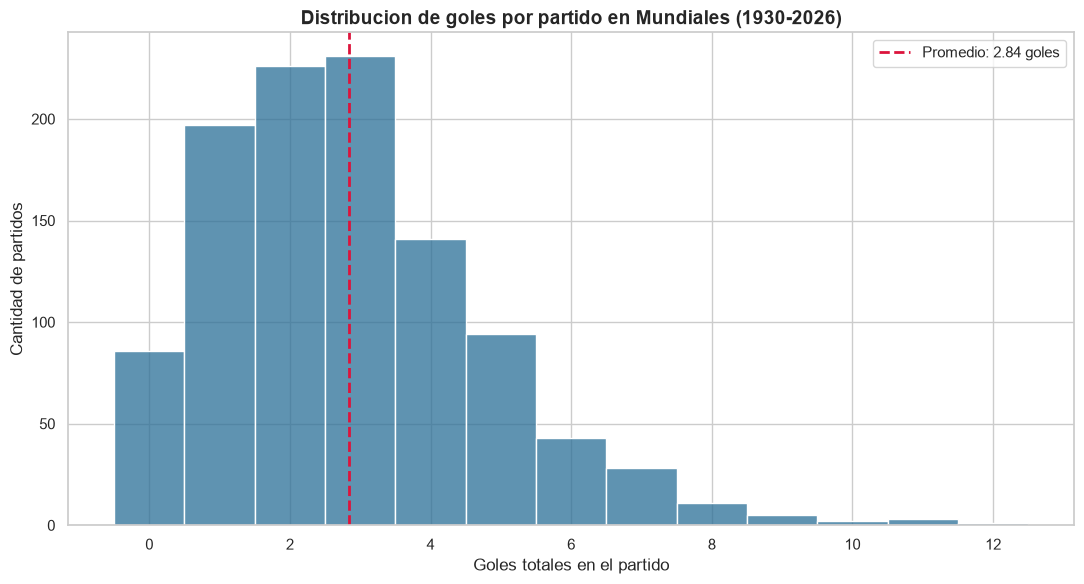

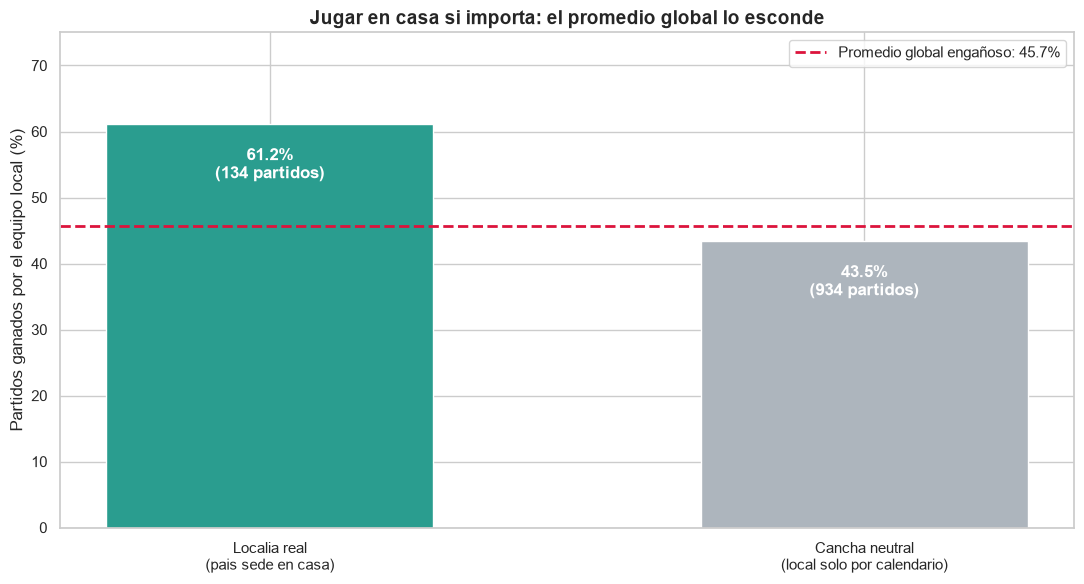

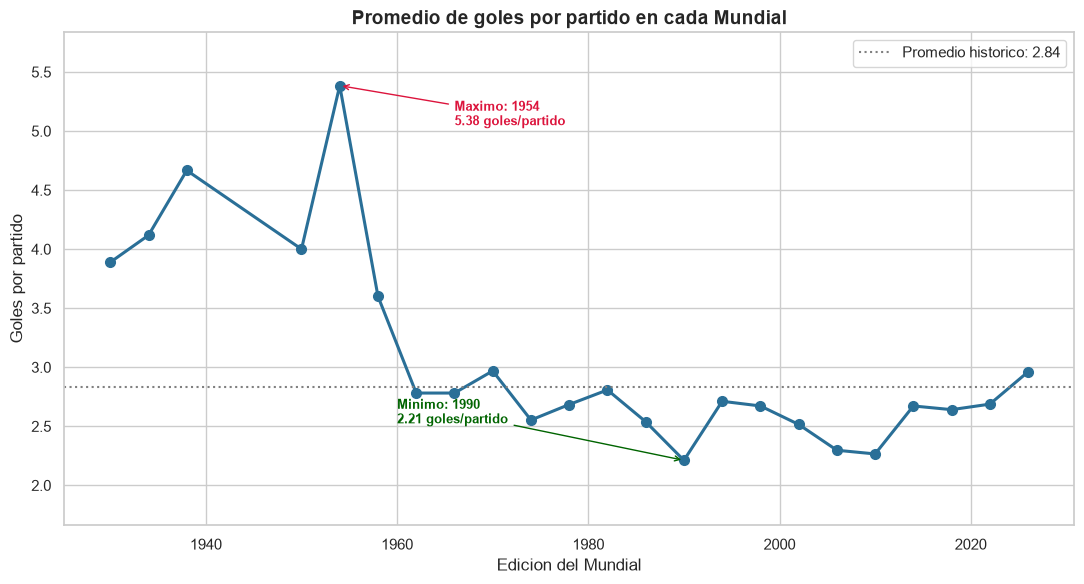

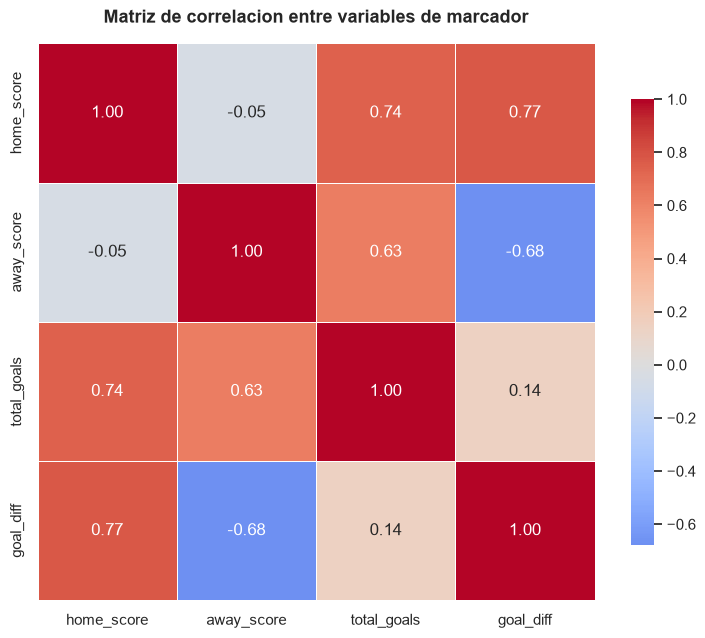

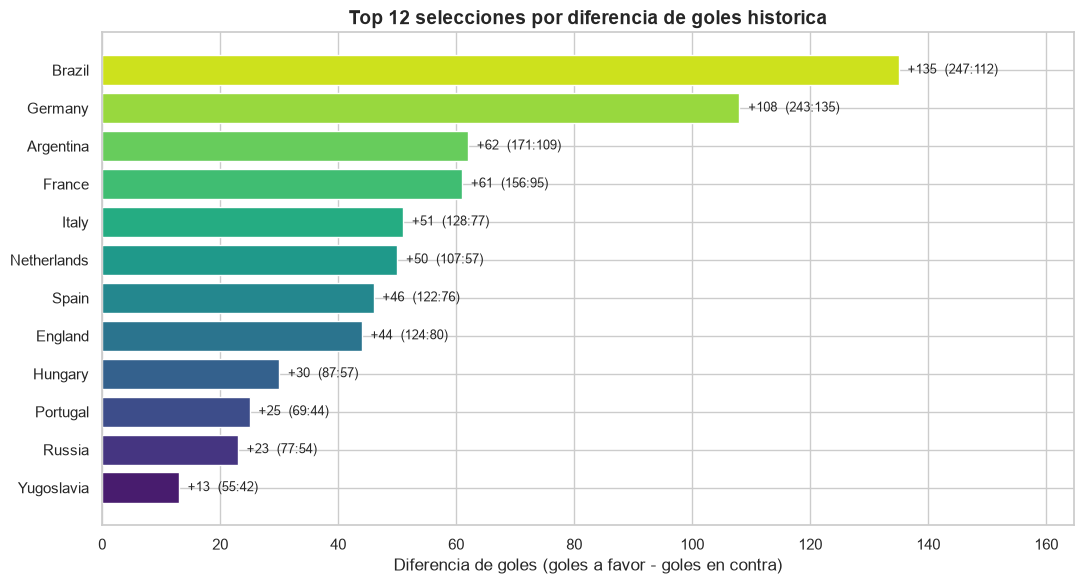

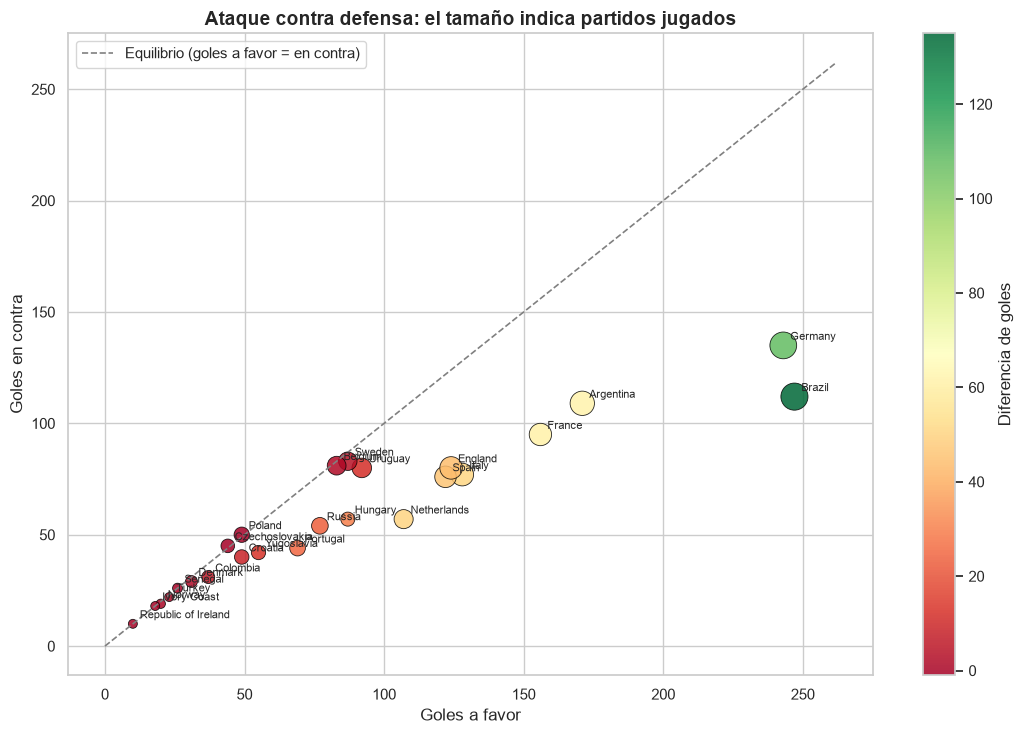

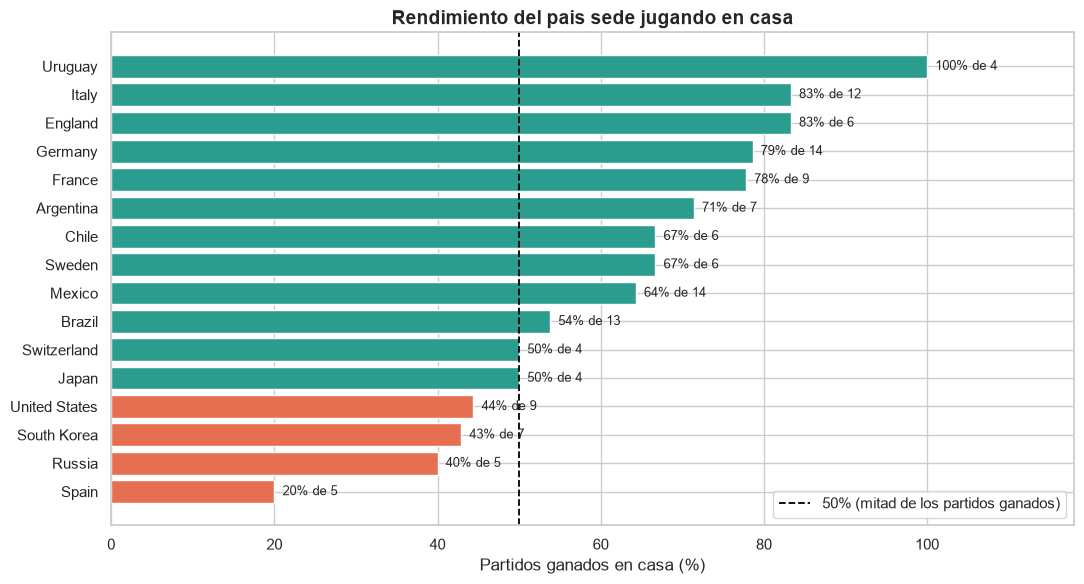

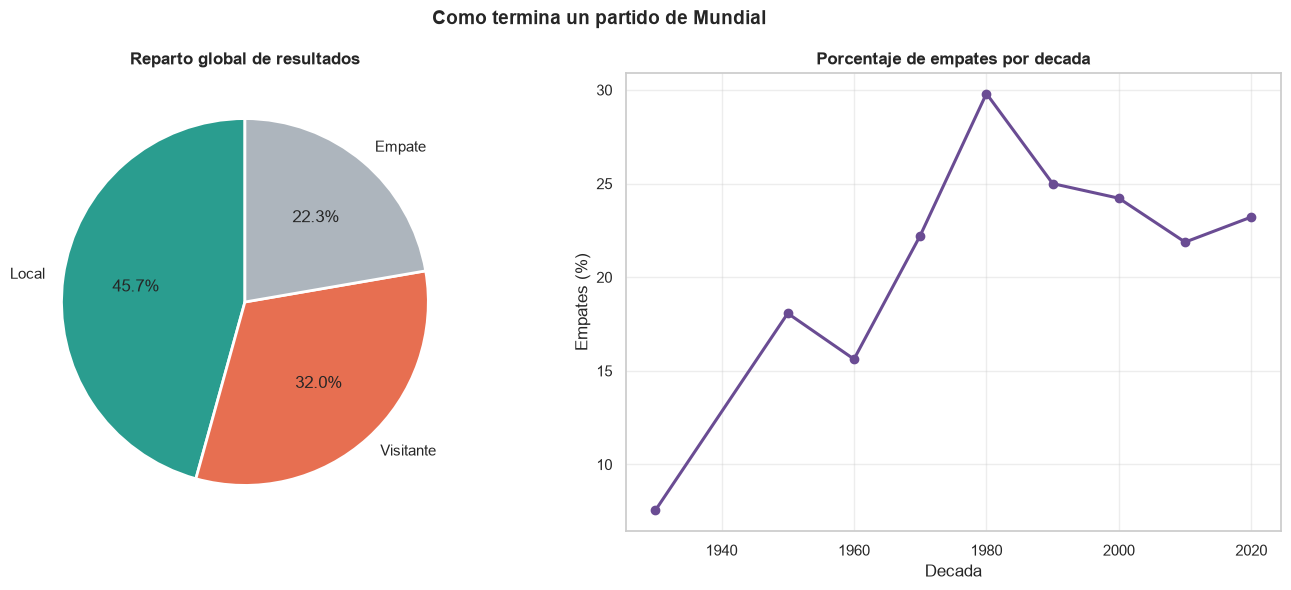

In [13]:
viz.generar_todos(tabla, sedes)

## 14. Conclusiones

| Pregunta | Respuesta |
|---|---|
| ¿El país sede gana más? | Sí: 61.2 % con localía real contra 43.5 % en cancha neutral |
| ¿En qué Mundial se metieron más goles por partido? | 1954, con 5.38 goles por partido |
| ¿Qué selección tiene la mejor diferencia de goles? | Brasil, con +135 |
| ¿Cómo termina un partido típico? | Victoria local (46 %), 2 o 3 goles en total |
| ¿El fútbol se volvió más defensivo? | Sí: de 5.38 (1954) a ~2.6 goles por partido hoy |

El hallazgo metodológicamente más interesante es la **paradoja de Simpson** en
la ventaja de local: un promedio global que apunta en dirección contraria a lo
que ocurre en cada subgrupo por separado.